# Análisis Exploratorio de Datos (EDA): Demografía y Rating en el Ajedrez

Estudio demográfico del padrón FIDE de jugadores activos (~437K registros), centrado en
la distribución por género, edad, categorías juveniles y su relación con las federaciones.

**Dataset:** `fide_players_active.parquet`

## Índice

0. [Estadísticos Descriptivos por Población](#0-estadísticos-descriptivos-por-población)
1. [Análisis Demográfico y de Elo](#1-análisis-demográfico-y-de-elo)
   - 1.1. Análisis global por Sexo
   - 1.2. Proporción por sexo según Federación (FED)
   - 1.3. Comparativa de rating global por sexo
   - 1.4. Análisis por categorías juveniles
   - 1.5. Categorías juveniles segmentadas por sexo
   - 1.6. Categorías juveniles por Federación
2. [Pirámides Poblacionales y Estructura Etaria](#2-pirámides-poblacionales-y-estructura-etaria)
   - 2.1. Histograma y densidad de edad global
   - 2.2. Pirámide poblacional bidireccional (M vs F)
3. [Edad vs. Rendimiento: Curvas Biológicas de Elo](#3-edad-vs-rendimiento-curvas-biológicas-de-elo)
   - 3.1. Mediana y percentiles de Elo por edad
   - 3.2. Banda de rendimiento etario (IQR + P99)
   - 3.3. Comparación multimodal del declive (Clásico vs Rápido vs Blitz)
   - 3.4. La élite veterana: rendimiento después de los 50
4. [Análisis Profundo de Género y Brecha de Participación](#4-análisis-profundo-de-género-y-brecha-de-participación)
   - 4.1. Proporción de género por cohorte de edad
   - 4.2. El embudo de deserción: ¿a qué edad se ensancha la brecha?
   - 4.3. Hipótesis del tamaño de muestra (Chabris & Bilalić): test de percentiles
5. [Dinámica Geográfica y Relevo Generacional](#5-dinámica-geográfica-y-relevo-generacional)
   - 5.1. Edad mediana por Federación
   - 5.2. Federaciones jóvenes vs. envejecidas
   - 5.3. Tasa de participación femenina por país (Top/Bottom 10)
   - 5.4. Estructura de títulos según edad
6. [Síntesis de Hallazgos y Conclusiones](#6-síntesis-de-hallazgos-y-conclusiones)


In [18]:

%load_ext autoreload
%autoreload 


import pandas as pd
import numpy as np
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt 
import time

from src.analytics.univariateAnalyzer import UnivariateAnalyzer
from src.analytics.univariateVisualizer import UnivariateVisualizer



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. Estadísticos Descriptivos por Población

Resumen de medidas de tendencia central y dispersión para las tres segmentaciones principales.

In [19]:
df = pd.read_parquet('../data/processed/fide_players_active.parquet')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 437166 entries, 0 to 437165
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   fideid        437166 non-null  string  
 1   name          437166 non-null  string  
 2   country       437166 non-null  category
 3   sex           437166 non-null  category
 4   title         437166 non-null  category
 5   w_title       437166 non-null  category
 6   o_title       437166 non-null  category
 7   rating        219417 non-null  Int64   
 8   rapid_rating  324549 non-null  Int64   
 9   blitz_rating  203133 non-null  Int64   
 10  birthday      437166 non-null  Int64   
 11  flag          437166 non-null  category
 12  es_activo     437166 non-null  bool    
 13  edad          437166 non-null  Int64   
 14  categoria     437166 non-null  category
dtypes: Int64(5), bool(1), category(7), string(2)
memory usage: 40.2 MB


In [20]:
df.describe()

,rating,rapid_rating,blitz_rating,birthday,edad
count,219417.0,324549.0,203133.0,437166.0,437166.0
mean,1734.254137,1657.180201,1703.732402,1994.075658,31.924342
std,223.856323,200.865953,216.166838,19.752039,19.752039
min,1400.0,1400.0,1400.0,1931.0,4.0
25%,1556.0,1501.0,1533.0,1980.0,16.0
50%,1700.0,1611.0,1664.0,2001.0,25.0
75%,1873.0,1768.0,1833.0,2010.0,46.0
max,2823.0,2803.0,2860.0,2022.0,95.0


- Tabla que indica los estadisticos de la poblacion completa de jugadores activos registrados en la FIDE.

In [21]:
df[df["sex"] == "F"].describe()

,rating,rapid_rating,blitz_rating,birthday,edad
count,23620.0,31894.0,21050.0,42196.0,42196.0
mean,1631.36486,1581.759296,1613.867458,2004.611788,21.388212
std,196.673346,169.015086,181.770126,13.786952,13.786952
min,1400.0,1400.0,1400.0,1931.0,4.0
25%,1483.0,1460.0,1475.0,2003.0,13.0
50%,1572.0,1528.0,1561.0,2010.0,16.0
75%,1730.0,1650.0,1708.0,2013.0,23.0
max,2596.0,2529.0,2521.0,2022.0,95.0


- Tabla que indica los estadisticos de la poblacion completa de jugadores mujeres activas registradas en la FIDE.

In [22]:
df[df["sex"] == "M"].describe()

,rating,rapid_rating,blitz_rating,birthday,edad
count,195797.0,292655.0,182083.0,394970.0,394970.0
mean,1746.6662,1665.399689,1714.121384,1992.950047,33.049953
std,223.740325,202.34541,217.414676,19.959719,19.959719
min,1400.0,1400.0,1400.0,1931.0,4.0
25%,1570.0,1508.0,1543.0,1978.0,16.0
50%,1715.0,1622.0,1677.0,2000.0,26.0
75%,1885.0,1778.0,1844.0,2010.0,48.0
max,2823.0,2803.0,2860.0,2022.0,95.0


- Tabla que indica los estadisticos de la poblacion completa de jugadores hombres activos registrados en la FIDE.

## 1. Análisis Demográfico y de Elo

Análisis de la composición demográfica del padrón FIDE por género, federación
y categorías juveniles oficiales del ajedrez internacional.


### 1.1. Análisis Global por Sexo

Distribución absoluta y porcentual del padrón activo entre hombres (M) y mujeres (F).
- ¿Cuál es la proporción real de participación femenina a nivel global?


In [23]:
df_genero = df['sex'].value_counts().reset_index()

df_genero['proporcion'] = df_genero['count'] / df_genero['count'].sum() 
df_genero['porcentaje'] = np.round(df_genero['proporcion'], 2) * 100

df_genero

,sex,count,proporcion,porcentaje
0,M,394970,0.903478,90.0
1,F,42196,0.096522,10.0


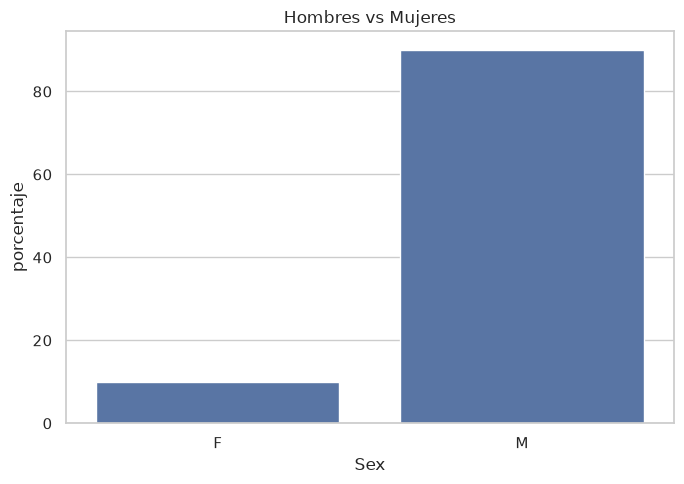

In [24]:
fig, ax = plt.subplots(figsize=(7,5))

sns.barplot(x=df_genero['sex'], y=df_genero['porcentaje'])
ax.set_title('Hombres vs Mujeres')
ax.set_xlabel('Sex')
ax.set_ylabel('porcentaje')

plt.tight_layout()
plt.show()

El 90% de los jugadores de ajedrez en todo el mundo son hombres, mientras que el 10% son mujeres. Esto indica que el ajedrez es un juego mayormente jugado por hombres, por lo que tenemos datos insuficientes para comparar ambas poblaciones. El modelo debe contemplar esto y no presentar sesgos en torno al género.

### 1.2. Proporción por Sexo según Federación (FED)

Dos perspectivas complementarias:
- **Proporción global:** ¿Qué porcentaje del total mundial de mujeres/hombres aporta cada federación?
- **Proporción interna:** Dentro de cada federación, ¿qué porcentaje son mujeres vs hombres?

Esto permite distinguir entre federaciones grandes (que aportan mucho volumen absoluto)
y federaciones con alta inclusión


- Tabla que muestra la proporcion de jugadores mujeres y hombres que tiene la federacion con respecto al total global. 

In [25]:

df_genero_FED = (
    pd.crosstab(index=df['country'], columns=df['sex'])
    .assign(total=lambda x: x.sum(axis=1))   
    .sort_values(by='total', ascending=False) 
    .reset_index()                            
)

df_genero_FED_global = df_genero_FED.copy()

df_genero_FED_global['h_F'] = df_genero_FED_global['F'] / df_genero_FED_global['total'].sum()
df_genero_FED_global['h_M'] = df_genero_FED_global['M'] / df_genero_FED_global['total'].sum()
df_genero_FED_global['h_F%'] = df_genero_FED_global['h_F'] * 100
df_genero_FED_global['h_M%'] = df_genero_FED_global['h_M'] * 100

df_genero_FED_global.head()


sex,country,F,M,total,h_F,h_M,h_F%,h_M%
0,IND,4331,30650,34981,0.009907,0.070111,0.990699,7.011067
1,RUS,4798,29506,34304,0.010975,0.067494,1.097524,6.749381
2,FRA,2420,29861,32281,0.005536,0.068306,0.553565,6.830586
3,ESP,1284,21508,22792,0.002937,0.049199,0.293710,4.919870
4,IRI,1674,18563,20237,0.003829,0.042462,0.382921,4.246213


In [26]:
print(f' [%] Total de mujeres: {df_genero_FED_global['h_F%'].sum()}')
print(f' [%] Total de hombres: {df_genero_FED_global['h_M%'].sum()}')

 [%] Total de mujeres: 9.65216874139343
 [%] Total de hombres: 90.34783125860656


- Tabla que muestra la proporcion de jugadores mujeres y hombres con respecto al total de jugadores de su Federacion. 

In [27]:


df_genero_FED['h_F'] = df_genero_FED['F'] / df_genero_FED['total']
df_genero_FED['h_M'] = df_genero_FED['M'] / df_genero_FED['total']
df_genero_FED['h_F%'] = np.round(df_genero_FED['h_F'],2) * 100
df_genero_FED['h_M%'] = np.round(df_genero_FED['h_M'],2) * 100

df_genero_FED.head()

sex,country,F,M,total,h_F,h_M,h_F%,h_M%
0,IND,4331,30650,34981,0.123810,0.876190,12.0,88.0
1,RUS,4798,29506,34304,0.139867,0.860133,14.0,86.0
2,FRA,2420,29861,32281,0.074967,0.925033,7.0,93.0
3,ESP,1284,21508,22792,0.056336,0.943664,6.0,94.0
4,IRI,1674,18563,20237,0.082720,0.917280,8.0,92.0


### 1.3. Comparativa de Rating Global por Sexo

Comparación de las distribuciones de Elo entre hombres y mujeres mediante:
- Diagrama de violín o KDE superpuesto.
- Diferencia de medianas y medias.



In [28]:
df_hombres = df[df['sex'] == 'M']
df_mujeres = df[df['sex'] == 'F']

#### 1.3.a. Distribución de Rating por Sexo — Visualización

Gráfico comparativo de la distribución de Elo clásico segmentado por género.


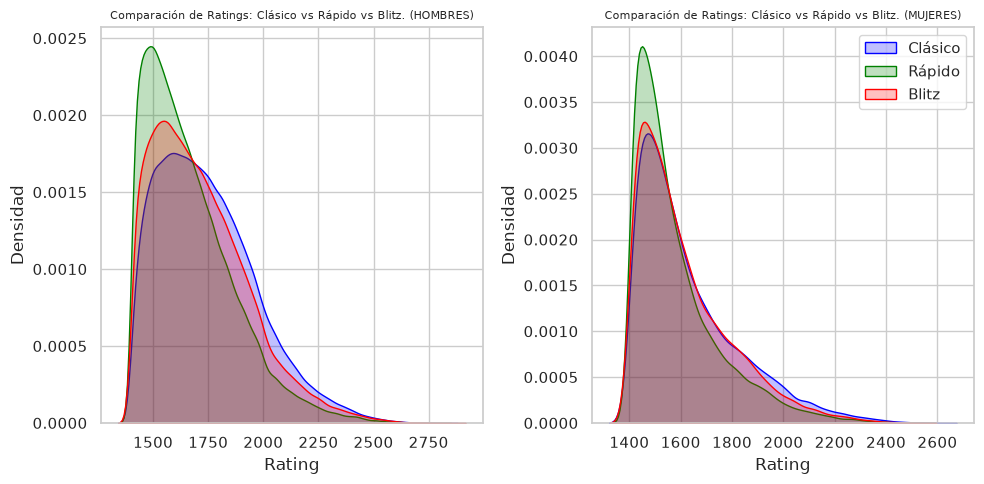

In [29]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1,2, figsize=(10,5))


sns.kdeplot(df_hombres[df_hombres['rating'] > 0]['rating'], fill=True, color='blue', label='Clásico', ax=ax[0])
sns.kdeplot(df_hombres[df_hombres['rapid_rating'] > 0]['rapid_rating'], fill=True, color='green', label='Rápido', ax=ax[0])
sns.kdeplot(df_hombres[df_hombres['blitz_rating'] > 0]['blitz_rating'], fill=True, color='red', label='Blitz', ax=ax[0])

ax[0].set_title('Comparación de Ratings: Clásico vs Rápido vs Blitz. (HOMBRES)', fontsize=8)
ax[0].set_xlabel('Rating', fontsize=12)
ax[0].set_ylabel('Densidad', fontsize=12)


sns.kdeplot(df_mujeres[df_mujeres['rating'] > 0]['rating'], fill=True, color='blue', label='Clásico', ax=ax[1])
sns.kdeplot(df_mujeres[df_mujeres['rapid_rating'] > 0]['rapid_rating'], fill=True, color='green', label='Rápido',ax=ax[1])
sns.kdeplot(df_mujeres[df_mujeres['blitz_rating'] > 0]['blitz_rating'], fill=True, color='red', label='Blitz', ax=ax[1])

ax[1].set_title('Comparación de Ratings: Clásico vs Rápido vs Blitz. (MUJERES)', fontsize=8)
ax[1].set_xlabel('Rating', fontsize=12)
ax[1].set_ylabel('Densidad', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

### 1.4. Análisis por Categorías Juveniles

Distribución del padrón activo según las categorías oficiales del ajedrez (Sub-8 a Absoluta).
- ¿Cuál es la categoría con mayor cantidad de jugadores activos?
- ¿La distribución sugiere una base juvenil amplia o un padrón concentrado en adultos?


In [134]:

df_categorias = df['categoria'].value_counts().reset_index()
df_categorias['%'] = np.round((df_categorias['count'] / df_categorias['count'].sum()) * 100, 2) 

df_categorias = df_categorias.sort_values('categoria').reset_index(drop=True)

df_categorias



,categoria,count,%
0,Sub 8,1013,0.23
1,Sub 10,8093,1.85
2,Sub 12,22110,5.06
3,Sub 14,34578,7.91
4,Sub 16,40324,9.22
5,Sub 18,36643,8.38
6,Sub 20,28362,6.49
7,Absoluta,266043,60.86


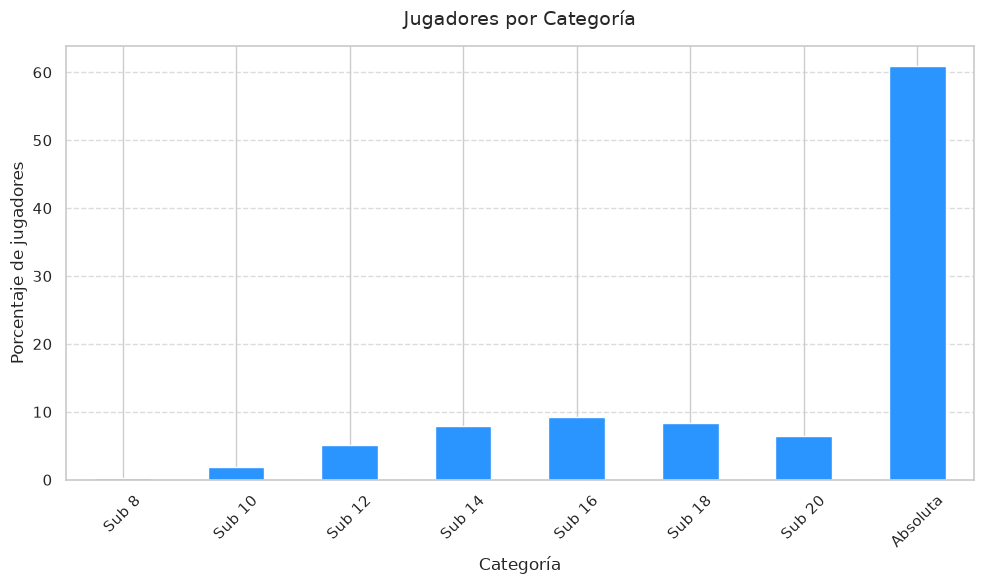

In [160]:

fig, ax = plt.subplots(figsize=(10, 6))

df_categorias.set_index('categoria')['%'].plot(
    kind='bar', 
    stacked=True, 
    color=["#2b95ff"], 
    ax=ax 
)

ax.set_title('Jugadores por Categoría', fontsize=14, pad=15)
ax.set_xlabel('Categoría', fontsize=12)
ax.set_ylabel('Porcentaje de jugadores', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)


fig.tight_layout()
plt.show()

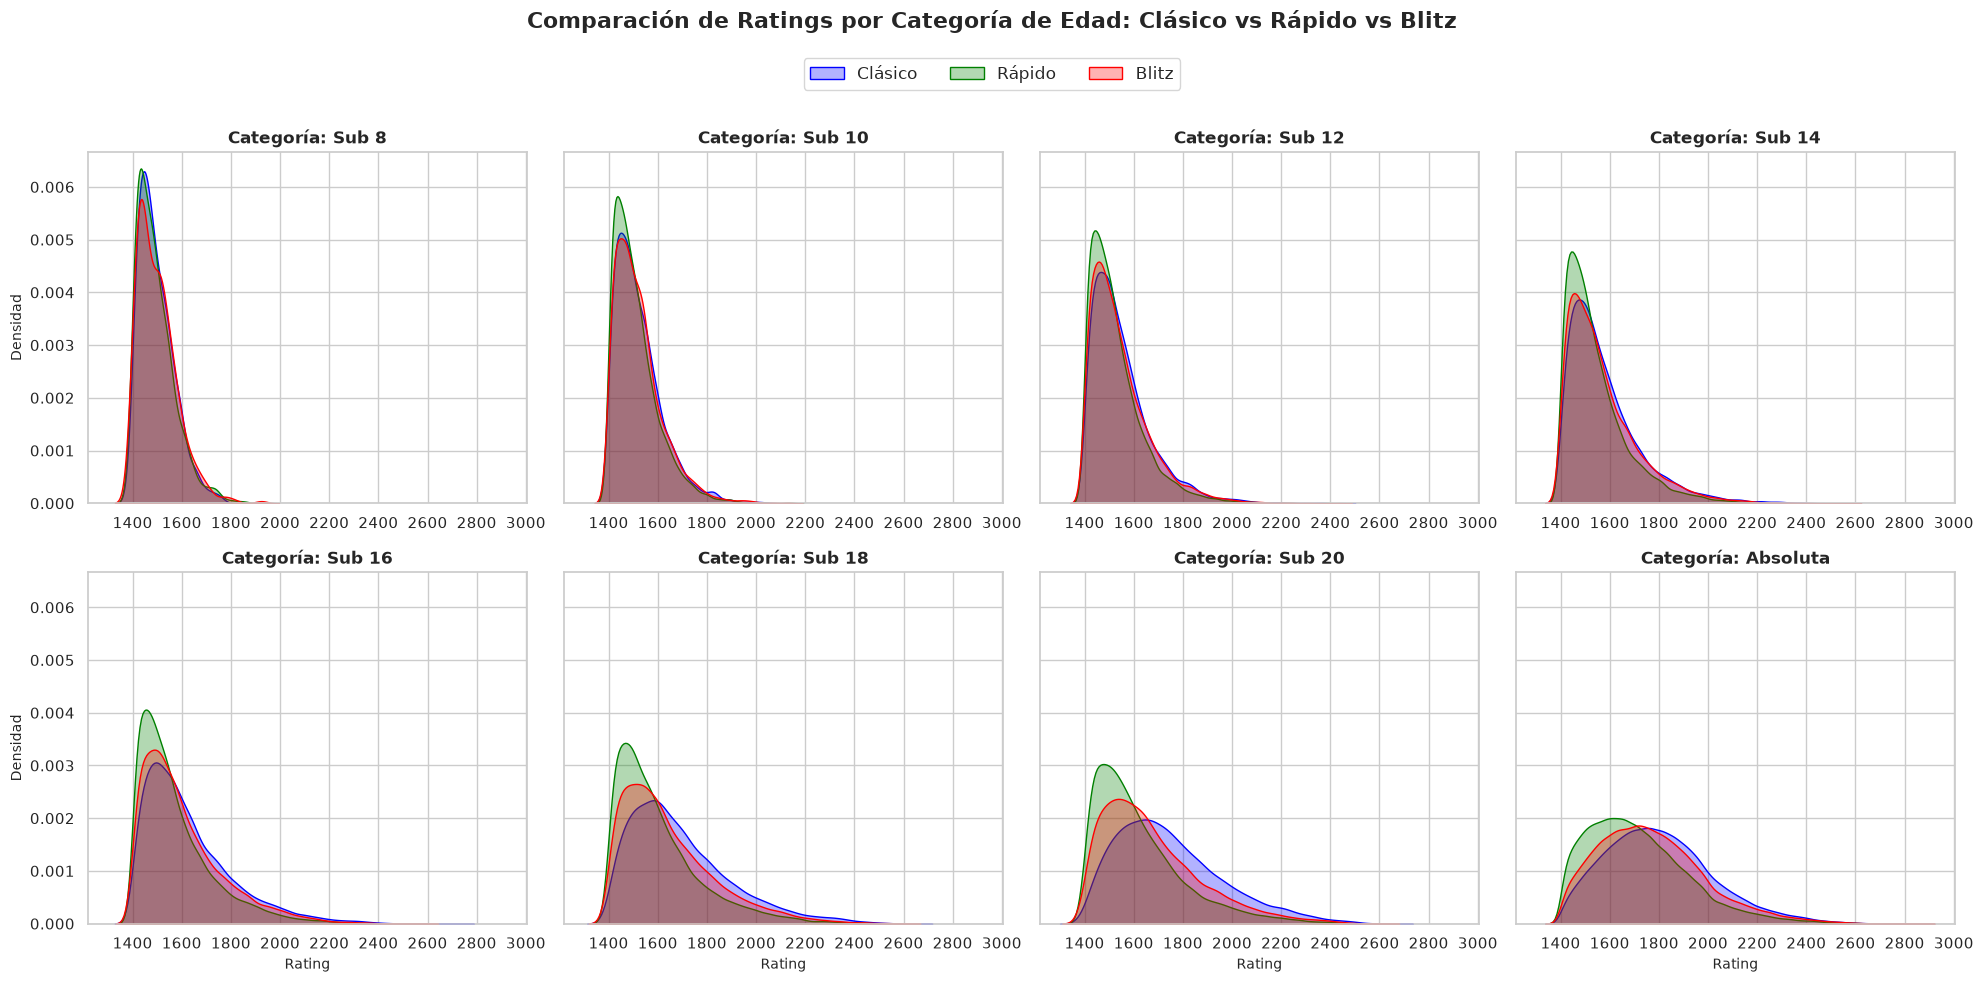

In [161]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()

categorias = list(df_categorias['categoria'])

for i, cat in enumerate(categorias):
    ax = axes[i]
    df_cat = df[df["categoria"] == cat]

    clasico = df_cat[df_cat["rating"] > 0]["rating"]
    rapido = df_cat[df_cat["rapid_rating"] > 0]["rapid_rating"]
    blitz = df_cat[df_cat["blitz_rating"] > 0]["blitz_rating"]

    if len(clasico) > 1 and clasico.nunique() > 1:
        sns.kdeplot(
            clasico, fill=True, color="blue", label="Clásico", ax=ax, alpha=0.3
        )
    if len(rapido) > 1 and rapido.nunique() > 1:
        sns.kdeplot(
            rapido, fill=True, color="green", label="Rápido", ax=ax, alpha=0.3
        )
    if len(blitz) > 1 and blitz.nunique() > 1:
        sns.kdeplot(
            blitz, fill=True, color="red", label="Blitz", ax=ax, alpha=0.3
        )

    ax.set_title(f"Categoría: {cat}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Rating", fontsize=10)
    ax.set_ylabel("Densidad", fontsize=10)
    ax.tick_params(labelbottom=True)

plt.suptitle(
    "Comparación de Ratings por Categoría de Edad: Clásico vs Rápido vs Blitz",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.94),
        ncol=3,
        fontsize=12,
    )

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### 1.5. Categorías Juveniles Segmentadas por Sexo

Crosstab de categoría etaria × género para examinar:
- ¿La proporción de niñas es mayor en las categorías infantiles (Sub-8, Sub-10) que en las juveniles (Sub-16, Sub-18)?
- ¿Se observa una caída progresiva de participación femenina conforme sube la edad?


In [162]:

df_categoria_seg = pd.crosstab(df['categoria'], df['sex']).reset_index()

df_categoria_seg['F%'] = np.round((df_categoria_seg['F'] / df_categoria_seg[['F','M']].sum(axis=1)) * 100,2)
df_categoria_seg['M%'] = np.round((df_categoria_seg['M'] / df_categoria_seg[['F','M']].sum(axis=1)) * 100,2)
df_categoria_seg

sex,categoria,F,M,F%,M%
0,Sub 8,180,833,17.77,82.23
1,Sub 10,1463,6630,18.08,81.92
2,Sub 12,4076,18034,18.44,81.56
3,Sub 14,6185,28393,17.89,82.11
4,Sub 16,6497,33827,16.11,83.89
5,Sub 18,5359,31284,14.62,85.38
6,Sub 20,3724,24638,13.13,86.87
7,Absoluta,14712,251331,5.53,94.47


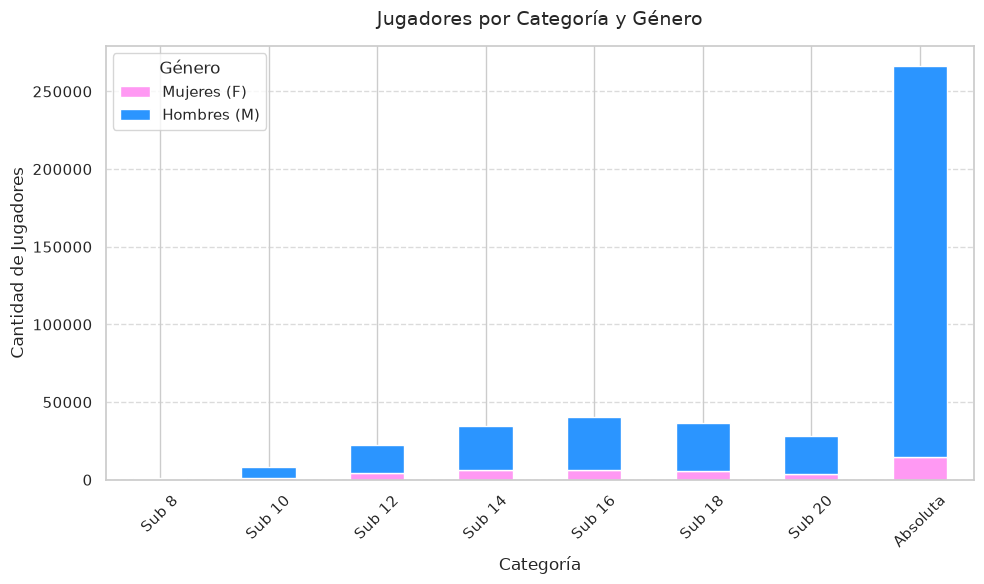

In [163]:

fig, ax = plt.subplots(figsize=(10, 6))

df_categoria_seg.set_index('categoria')[['F', 'M']].plot(
    kind='bar', 
    stacked=True, 
    color=["#ff99f3", "#2b95ff"], 
    ax=ax 
)

ax.set_title('Jugadores por Categoría y Género', fontsize=14, pad=15)
ax.set_xlabel('Categoría', fontsize=12)
ax.set_ylabel('Cantidad de Jugadores', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Género', labels=['Mujeres (F)', 'Hombres (M)'])
ax.grid(axis='y', linestyle='--', alpha=0.7)


fig.tight_layout()
plt.show()

### 1.6. Categorías Juveniles por Federación

Cruce de categoría etaria × federación para identificar:
- ¿Qué países tienen la base juvenil más amplia? 
- ¿Qué federaciones están concentradas en categoría Absoluta con poco relevo juvenil?


In [164]:
df_categoria_FED = (
    pd.crosstab(index=df['country'], columns=df['categoria'])
    .assign(total=lambda x: x.sum(axis=1))   
    .sort_values(by='total', ascending=False) 
    .reset_index()                            
)

orden = [
    'total',
    'Sub 8', 
    'Sub 10', 
    'Sub 12', 
    'Sub 14', 
    'Sub 16', 
    'Sub 18', 
    'Sub 20',
    'Absoluta',
    'country' 
]

df_categoria_FED = df_categoria_FED[orden[::-1]]
df_categoria_FED = df_categoria_FED.rename_axis(None, axis=1)

df_categoria_FED.head()

,country,Absoluta,Sub 20,Sub 18,Sub 16,Sub 14,Sub 12,Sub 10,Sub 8,total
0,IND,12643,2073,3601,6126,5583,3338,1340,277,34981
1,RUS,17906,2488,3668,3819,3423,2281,670,49,34304
2,FRA,21154,1707,2414,2654,2267,1524,521,40,32281
3,ESP,16402,1068,1326,1606,1305,791,265,29,22792
4,IRI,11612,1394,1899,1957,1720,1178,428,49,20237


---

## 2. Pirámides Poblacionales y Estructura Etaria

Visualización de la estructura demográfica del ajedrez mundial por edad y género.


### 2.1. Histograma y Densidad de Edad Global

Distribución continua de la edad en el padrón activo mundial.
- Identificar la **moda** (edad con mayor cantidad de federados activos).
- Calcular media, mediana, desviación estándar, IQR, mínimo y máximo de edad.


### 2.2. Pirámide Poblacional Bidireccional (M vs F)

Pirámide demográfica del ajedrez mundial:
- Hombres a un lado, mujeres al otro.
- Agrupados en tramos de 5 años.
- Identificar la forma global: ¿expansiva, estacional o regresiva?
- Observar en qué franja etaria la presencia femenina experimenta su mayor reducción porcentual.


---

## 3. Edad vs. Rendimiento: Curvas Biológicas de Elo

Análisis de cómo evoluciona el rating en función de la edad del jugador.
Pregunta central: **¿A qué edad se alcanza el pico estadístico de rendimiento?**


### 3.1. Mediana y Percentiles de Elo por Edad

- Calcular media y mediana del Elo clásico para cada edad individual (8 a 80 años).
- Calcular percentiles clave: P25, P75, P95 y P99 por edad.
- Esto captura la evolución de la masa de aficionados frente a la élite.


### 3.2. Banda de Rendimiento Etario (IQR + P99)

- Curva de mediana de Elo + área sombreada del IQR (P25-P75).
- Superponer la curva del P99 (los mejores jugadores mundiales por cohorte).
- ¿La curva tiene forma de campana, parábola o meseta?


### 3.3. Comparación Multimodal del Declive (Clásico vs Rápido vs Blitz)

- Medianas de Elo en Clásico, Rápido y Blitz para cada año de edad.
- ¿A qué edad se alcanza el máximo en cada modalidad?
- ¿El Blitz decae antes que el Clásico? (hipótesis neuromotora: las modalidades rápidas dependen más de velocidad de procesamiento).
- Calcular pendiente de caída a partir de los 45 años.


### 3.4. La Élite Veterana: Rendimiento Después de los 50

- ¿Qué porcentaje de jugadores >50 y >65 años (categorías Senior FIDE) mantienen Elo >2000 y >2200?
- ¿Existe sesgo de supervivencia? (los veteranos que siguen activos suelen ser los más fuertes, sesgando la media hacia arriba).


---

## 4. Análisis Profundo de Género y Brecha de Participación

Más allá de la proporción global 90/10, se exploran las dinámicas de género
a lo largo de las cohortes de edad y los percentiles de rendimiento.


### 4.1. Proporción de Género por Cohorte de Edad

- Porcentaje de mujeres dentro de cada tramo etario (Sub-10, Sub-14, Sub-18, etc.).
- ¿El ajedrez infantil empieza con proporción cercana a paridad que luego se deteriora?
- ¿O la subrepresentación femenina existe desde las categorías Sub-8 y Sub-10?


### 4.2. El Embudo de Deserción: ¿A Qué Edad se Ensancha la Brecha?

- Curva de participación porcentual femenina vs. edad.
- Identificar la edad exacta donde la proporción femenina cae más drásticamente.
- Hipótesis: ¿"valle de deserción" en transición secundaria→universidad (17-21 años)?


### 4.3. Hipótesis del Tamaño de Muestra (Chabris & Bilalić): Test de Percentiles

Pregunta: ¿La menor presencia de mujeres en la superélite se explica simplemente
porque la base femenina es más pequeña (ley de valores extremos), o hay una disparidad
persistente al comparar percentiles relativos equivalentes?

**Metodología:**
- Calcular percentiles internos de cada grupo: P50, P90, P95, P99 de mujeres vs hombres.
- Analizar si la brecha absoluta (puntos Elo) se reduce al comparar rendimiento intrínseco.
- Si P95♀ ≈ P95♂ pero hay menos mujeres en 2500+, la hipótesis de muestra se sostiene.


---

## 5. Dinámica Geográfica y Relevo Generacional

Cruce de la demografía con la dimensión geográfica: ¿qué países tienen el futuro
del ajedrez y cuáles están envejeciendo?


### 5.1. Edad Mediana por Federación

- Calcular la edad mediana de jugadores activos para las 20 principales federaciones.


### 5.2. Federaciones Jóvenes vs. Envejecidas

Clasificar federaciones en dos grupos:
- **Jóvenes / En crecimiento:** Base predominantemente infantil y juvenil (ej. India, Uzbekistán).
- **Maduras / Envejecidas:** Padrón concentrado en adultos mayores y veteranos (ej. países europeos clásicos).


### 5.3. Tasa de Participación Femenina por País (Top/Bottom 10)

- **Top 10:** Países con mayor porcentaje de mujeres en su padrón (¿Georgia, China, Mongolia?).
- **Bottom 10:** Países con menor inclusión femenina.
- ¿Hay correlación con políticas estatales de fomento al ajedrez?


### 5.4. Estructura de Títulos Según Edad

- Edad promedio y mediana de titulados por categoría (GM, IM, FM, CM, WGM, WIM, WFM, WCM).
- ¿Qué proporción de GM mundiales tienen menos de 25 años?
- ¿Las potencias emergentes están titulando jugadores a edades más tempranas?


### 6.1. Hallazgos Clave

- [ ] Edad del pico biológico detectado y diferencia entre ritmos.
- [ ] Evidencia empírica sobre la brecha de género y momento de mayor deserción.
- [ ] Países que representan el motor generacional del ajedrez del futuro.


### 6.2. Sesgos y Limitaciones Metodológicas

- [ ] **Sesgo de supervivencia:** Los veteranos activos suelen ser los más fuertes/apasionados → sesga la media de Elo hacia arriba en edades avanzadas.
- [ ] **Snapshot único:** Sin datos temporales, no se puede distinguir efecto-edad de efecto-cohorte.
- [ ] **Ausencia de datos socioeconómicos:** No se puede controlar por variables externas (ingreso, acceso a entrenadores, cultura familiar).


### 6.3. Hipótesis Derivadas para Próximos Notebooks

- [ ] ¿La especialización en Blitz es un fenómeno generacional? → 
- [ ] ¿Los países con mayor inclusión femenina tienen mayor eficiencia formativa? → futuro notebook de geografía
- [ ] ¿La inflación del Elo afecta de forma diferente a distintas cohortes de edad? → requiere datos históricos
